<a href="https://colab.research.google.com/github/idkisma3l/ExamenPracticoFinal_ISI/blob/main/Proyecto_Examen_Final_ISID223_Google_Colab_Estilo_Dark_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/idkisma3l/ExamenPracticoFinal_ISI/blob/main/Proyecto_Examen_Final_ISID223_Google_Colab_Estilo_Dark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Final Práctico - ISID223
Proyecto para Google Colab

In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import files

import plotly.io as pio
pio.renderers.default = 'png'


## Cargar archivo CSV

In [25]:
# Cargar la base de datos
df = pd.read_csv('/content/real_estate_ecuador_200k.csv')

# Mostrar las primeras filas
df.head()

print(df.shape)
print(len(df))

(200000, 8)
200000


## Perspectiva Financiera

In [10]:
# ================================
# PERSPECTIVA FINANCIERA
# ================================

# i. Precio Promedio de Alquiler (General y por Ciudad)

precio_promedio = df["Precio"].mean()

precio_ciudad = (
    df.groupby("Lugar")["Precio"]
      .mean()
      .reset_index()
      .rename(columns={
          "Lugar": "Ciudad",
          "Precio": "Precio Promedio"
      })
      .sort_values(by="Precio Promedio", ascending=False)
)

print("i. Precio Promedio General de Alquiler")
display(pd.DataFrame({
    "Indicador": ["Precio Promedio General"],
    "Valor": [round(precio_promedio, 2)]
}))

print("Precio Promedio por Ciudad")
display(precio_ciudad)


# ============================================
# ii. Costo Promedio por Metro Cuadrado
# ============================================

df["Costo_m2"] = df["Precio"] / df["Area"]

costo_m2 = df["Costo_m2"].mean()

print("ii. Costo Promedio por Metro Cuadrado")
display(pd.DataFrame({
    "Indicador": ["Costo Promedio por m²"],
    "Valor": [round(costo_m2, 2)]
}))


# ============================================
# iii. Rango de Precios por Provincia
# ============================================

rango_provincia = (
    df.groupby("Provincia")["Precio"]
      .agg(
          Precio_Minimo="min",
          Precio_Maximo="max",
          Precio_Promedio="mean"
      )
      .reset_index()
)

print("iii. Rango de Precios (Mínimo, Máximo y Promedio) por Provincia")
display(rango_provincia)

i. Precio Promedio General de Alquiler


,Indicador,Valor
0,Precio Promedio General,730.92


Precio Promedio por Ciudad


,Ciudad,Precio Promedio
99,"Pichincha, Avenida 10 de Agosto, Quito, Ecuador",9010.780326
38,"Manabí, Manta, Ecuador",6502.367957
215,"Pichincha, La Delicia, Quito, Ecuador",4947.350642
189,"Pichincha, Guamaní, Quito, Ecuador",3859.586983
0,"Cotopaxi, Latacunga, Cotopaxi, Ecuador",3715.924566
...,...,...
293,"Pichincha, Turubamaba, Ecuador",121.080284
1,"Cotopaxi, Latacunga, Ecuador",118.513827
145,"Pichincha, Comité del Pueblo, Quito, Ecuador",115.363495
249,"Pichincha, Nueva Aurora, Quito, Ecuador",100.015449


ii. Costo Promedio por Metro Cuadrado


,Indicador,Valor
0,Costo Promedio por m²,5.9


iii. Rango de Precios (Mínimo, Máximo y Promedio) por Provincia


,Provincia,Precio_Minimo,Precio_Maximo,Precio_Promedio
0,Cotopaxi,94.47,4470.59,1805.104770
1,El Oro,98.42,155.03,124.432098
2,Esmeraldas,111.39,611.54,322.589521
3,Guayas,130.85,2794.28,615.222958
4,Imbabura,380.54,589.42,482.100058
5,Los Rios,176.04,295.08,233.454810
6,Manabí,5231.47,7861.31,6502.367957
7,Orellana,120.64,185.84,148.778343
8,Pichincha,82.12,10946.90,732.676548
9,Santa Elena,7.24,11.03,8.910447


## Perspectiva Producto

In [11]:
def tipo_propiedad(texto):
    texto = str(texto).lower()
    if "suite" in texto:
        return "Suite"
    elif "departamento" in texto:
        return "Departamento"
    elif "casa" in texto:
        return "Casa"
    elif "local" in texto:
        return "Local Comercial"
    elif "oficina" in texto:
        return "Oficina"
    elif "terreno" in texto:
        return "Terreno"
    else:
        return "Otro"

df["Tipo"] = df["Titulo"].apply(tipo_propiedad)

conteo_tipo = df["Tipo"].value_counts()
tamano_promedio = df.groupby("Provincia")["Area"].mean()

precio_habitaciones = df.groupby("Num. dormitorios")["Precio"].mean().sort_index()
premium = precio_habitaciones.diff()

display(conteo_tipo)
display(tamano_promedio)
display(premium)

,count
Tipo,
Departamento,37000
Suite,11231
Oficina,9953
Otro,9888
Local Comercial,9207
Casa,8722
Terreno,524


,Area
Provincia,
Cotopaxi,72.176152
El Oro,5965.511494
Esmeraldas,109.239437
Guayas,102.700152
Imbabura,141.380117
Los Rios,89.012111
Manabí,199.919355
Orellana,27.817680
Pichincha,166.595909


,Precio
Num. dormitorios,
1.0,NaN
2.0,-92.871674
3.0,92.239249
4.0,481.294378
5.0,244.965774
6.0,230.370891
7.0,1184.323664
8.0,-1904.349805
9.0,-405.993506


## Perspectiva Geográfica

In [12]:
top5 = df.groupby("Lugar")["Precio"].mean().sort_values(ascending=False).head(5)
oferta = df["Provincia"].value_counts()

display(top5)
display(oferta)

,Precio
Lugar,
"Pichincha, Avenida 10 de Agosto, Quito, Ecuador",9010.780326
"Manabí, Manta, Ecuador",6502.367957
"Pichincha, La Delicia, Quito, Ecuador",4947.350642
"Pichincha, Guamaní, Quito, Ecuador",3859.586983
"Cotopaxi, Latacunga, Cotopaxi, Ecuador",3715.924566


,count
Provincia,
Pichincha,78225
Guayas,5933
Los Rios,578
Cotopaxi,369
Esmeraldas,355
El Oro,348
Manabí,186
Orellana,181
Santa Elena,179


## Segmentación del Mercado

In [13]:
Q1 = df["Precio"].quantile(0.25)
Q3 = df["Precio"].quantile(0.75)

def segmento(precio):
    if precio < Q1:
        return "Económico"
    elif precio > Q3:
        return "Lujo"
    else:
        return "Medio"

df["Tipo de Inmueble"] = df["Precio"].apply(segmento)
display(df["Tipo de Inmueble"].value_counts())

,count
Tipo de Inmueble,
Medio,43264
Lujo,21631
Económico,21630


# Total de propiedades

len(df) = 200000


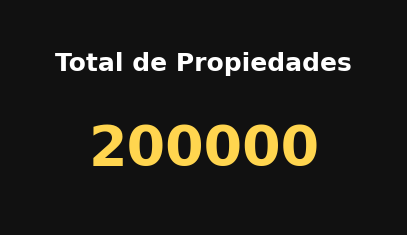

In [26]:
print("len(df) =", len(df))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.8))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")
ax.axis("off")

ax.text(0.5, 0.75, "Total de Propiedades",
        ha="center", va="center",
        fontsize=18, fontweight="bold", color="white")

ax.text(0.5, 0.35, str(len(df)),
        ha="center", va="center",
        fontsize=40, fontweight="bold", color="#FFD54F")

plt.show()

## Precio Promedio

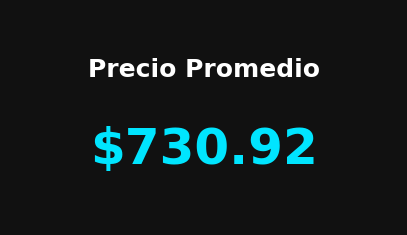

In [16]:
# ==========================
# KPI 1 - Precio Promedio
# ==========================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.8))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Ocultar ejes
ax.axis("off")

# Título
ax.text(
    0.5, 0.72,
    "Precio Promedio",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="white"
)

# Valor del KPI
ax.text(
    0.5, 0.35,
    f"${precio_promedio:,.2f}",
    ha="center",
    va="center",
    fontsize=36,
    fontweight="bold",
    color="#00E5FF"
)

plt.show()

# Costo promedio por m²

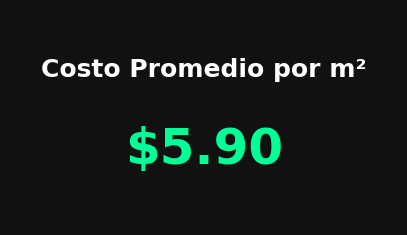

In [17]:
# ==========================
# KPI 2 - Costo Promedio por m²
# ==========================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.8))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Ocultar ejes
ax.axis("off")

# Título
ax.text(
    0.5, 0.72,
    "Costo Promedio por m²",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="white"
)

# Valor del KPI
ax.text(
    0.5, 0.35,
    f"${costo_m2:,.2f}",
    ha="center",
    va="center",
    fontsize=36,
    fontweight="bold",
    color="#00FF95"
)

plt.show()

# Precio promedio por provincia

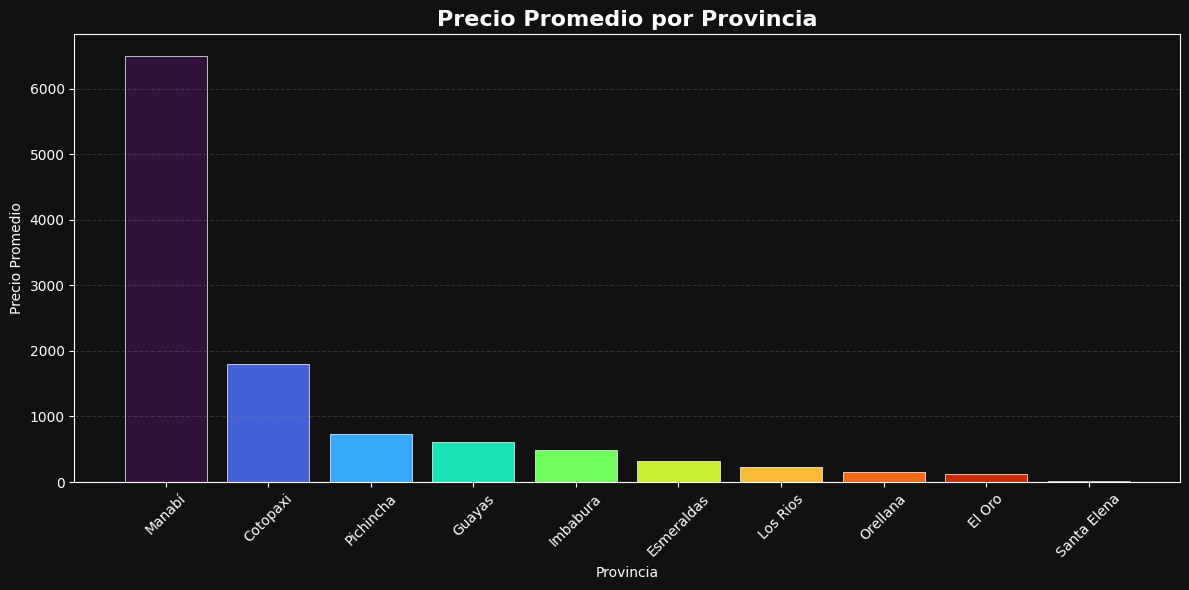

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# KPI: Precio promedio por provincia

precio_provincia = df.groupby("Provincia")["Precio"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Colores degradados
colors = plt.cm.turbo(np.linspace(0, 1, len(precio_provincia)))

# Barras
ax.bar(
    precio_provincia.index,
    precio_provincia.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Títulos
ax.set_title(
    "Precio Promedio por Provincia",
    color="white",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Provincia", color="white")
ax.set_ylabel("Precio Promedio", color="white")

# Colores de los ejes
ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

# Color de los bordes
for spine in ax.spines.values():
    spine.set_color("white")

# Líneas de referencia
ax.grid(axis="y", color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Promedio por ciudad

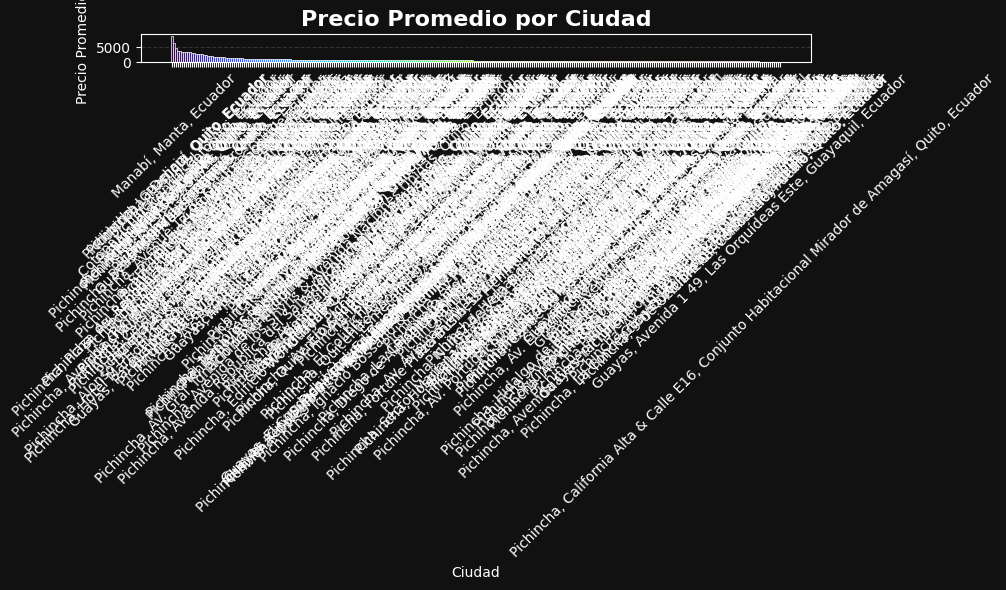

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# KPI 3.1 - Precio Promedio por Ciudad

fig, ax = plt.subplots(figsize=(10, 6))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Colores degradados
colors = plt.cm.turbo(np.linspace(0, 1, len(precio_ciudad)))

# Barras
ax.bar(
    precio_ciudad["Ciudad"],
    precio_ciudad["Precio Promedio"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Título y etiquetas
ax.set_title(
    "Precio Promedio por Ciudad",
    color="white",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Ciudad", color="white")
ax.set_ylabel("Precio Promedio", color="white")

# Personalizar ejes
ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

# Bordes
for spine in ax.spines.values():
    spine.set_color("white")

# Cuadrícula
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")

plt.tight_layout()
plt.show()

## Relación AREA VS PRECIO

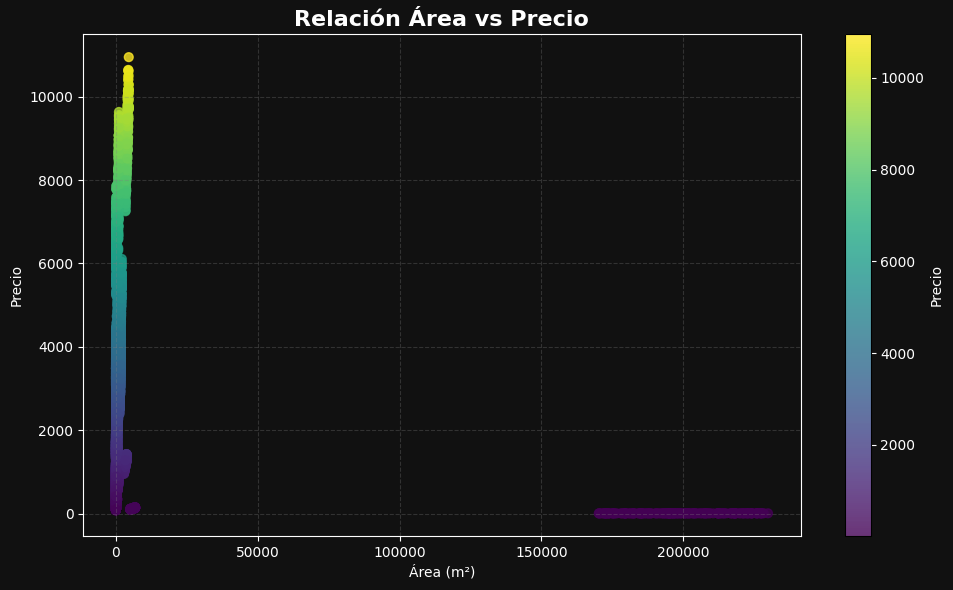

In [23]:
import matplotlib.pyplot as plt

# KPI 3.2 - Relación Área vs Precio

fig, ax = plt.subplots(figsize=(10, 6))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Gráfico de dispersión
scatter = ax.scatter(
    df["Area"],
    df["Precio"],
    c=df["Precio"],
    cmap="viridis",
    s=40,
    alpha=0.8
)

# Barra de colores
cbar = plt.colorbar(scatter)
cbar.set_label("Precio", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

# Título y etiquetas
ax.set_title(
    "Relación Área vs Precio",
    color="white",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Área (m²)", color="white")
ax.set_ylabel("Precio", color="white")

# Colores de ejes
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Bordes
for spine in ax.spines.values():
    spine.set_color("white")

# Cuadrícula
ax.grid(True, linestyle="--", alpha=0.3, color="gray")

plt.tight_layout()
plt.show()

# Distribución por propiedades / Premium por habitación

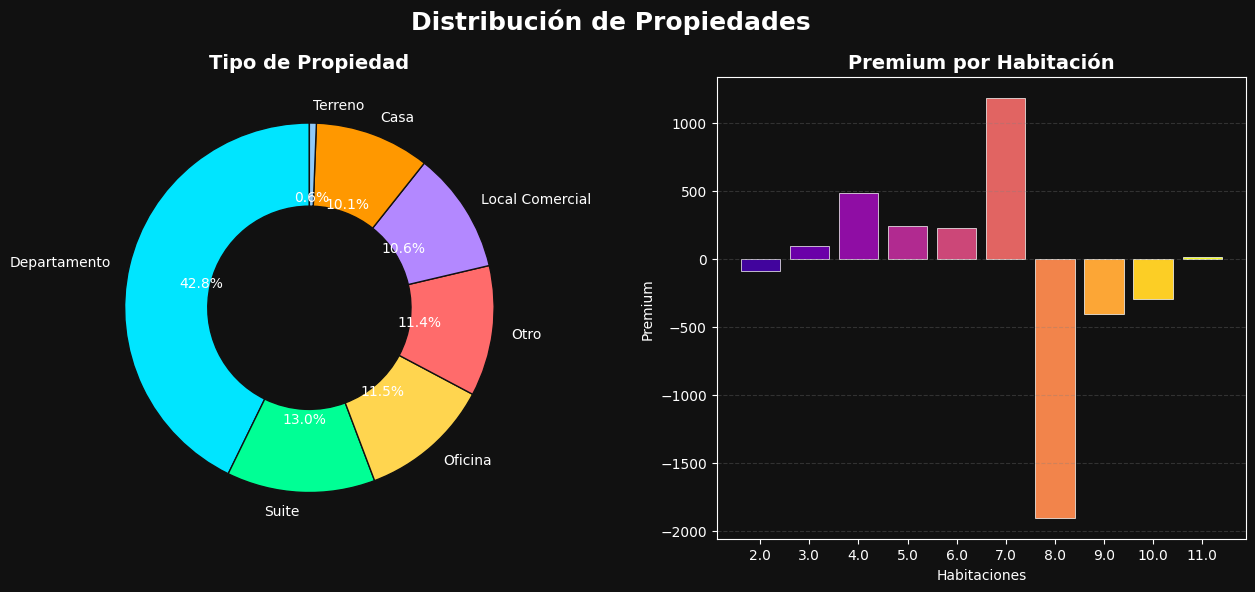

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Crear figura con dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Fondo oscuro
fig.patch.set_facecolor("#111111")
ax1.set_facecolor("#111111")
ax2.set_facecolor("#111111")

# ==========================
# Gráfico de pastel
# ==========================

colors = [
    "#00E5FF",
    "#00FF95",
    "#FFD54F",
    "#FF6B6B",
    "#B388FF",
    "#FF9800",
    "#90CAF9"
]

ax1.pie(
    conteo_tipo.values,
    labels=conteo_tipo.index,
    colors=colors[:len(conteo_tipo)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="#111111"),
    textprops={"color": "white"}
)

ax1.set_title(
    "Tipo de Propiedad",
    color="white",
    fontsize=14,
    fontweight="bold"
)

# ==========================
# Gráfico de barras
# ==========================

bar_colors = plt.cm.plasma(np.linspace(0, 1, len(premium)))

ax2.bar(
    premium.index.astype(str),
    premium.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5
)

ax2.set_title(
    "Premium por Habitación",
    color="white",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Habitaciones", color="white")
ax2.set_ylabel("Premium", color="white")

ax2.tick_params(axis="x", colors="white")
ax2.tick_params(axis="y", colors="white")

for spine in ax2.spines.values():
    spine.set_color("white")

ax2.grid(axis="y", linestyle="--", alpha=0.3, color="gray")

# Título general
fig.suptitle(
    "Distribución de Propiedades",
    color="white",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()